In [61]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [62]:
df_anual = pd.read_csv('dados_anuais_novo.csv')
df_anual.info()

<class 'pandas.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                1606 non-null   str    
 1   Especificação            1606 non-null   str    
 2   Porcentagens             1606 non-null   float64
 3   Incrementos/Decrementos  1606 non-null   float64
 4   Ano                      1606 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 62.9 KB


In [63]:
df_mensal = pd.read_csv('dados_mensais_novo.csv')
df_mensal.info()

<class 'pandas.DataFrame'>
RangeIndex: 17336 entries, 0 to 17335
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                17336 non-null  str    
 1   Especificação            17336 non-null  str    
 2   Porcentagens             17336 non-null  float64
 3   Incrementos/Decrementos  17336 non-null  float64
 4   Mês                      17336 non-null  str    
 5   Ano                      17336 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 812.8 KB


## Análise RAM

In [ ]:
df_ram = df_anual[df_anual['Categoria'] == 'System RAM']
df_ram = df_ram[(df_ram['Especificação'] == '4 GB') |
                ( df_ram['Especificação'] == '8 GB') |
                (df_ram['Especificação'] == '16 GB') |
                (df_ram['Especificação'] == '32 GB') |
                (df_ram['Especificação'] == '64 GB')]
df_ram

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
24,System RAM,4 GB,6.00,-5.05,2019
28,System RAM,8 GB,30.69,-7.21,2019
36,System RAM,16 GB,46.37,15.10,2019
201,System RAM,4 GB,4.39,-3.10,2020
205,System RAM,8 GB,25.32,-9.65,2020
213,System RAM,16 GB,49.95,11.68,2020
387,System RAM,4 GB,3.64,-1.25,2021
391,System RAM,8 GB,21.96,-6.65,2021
399,System RAM,16 GB,47.43,3.59,2021
586,System RAM,4 GB,5.89,-1.63,2022


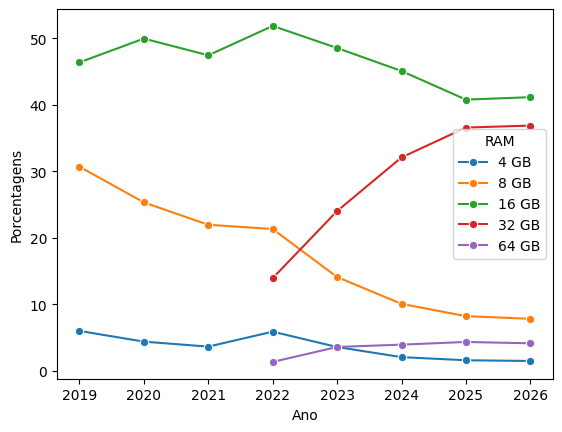

In [65]:
ax = sns.lineplot(data=df_ram, x='Ano', y='Porcentagens', hue='Especificação', marker='o')
ax.legend_.set_title(title="RAM")

In [66]:
df_ram_8 = df_ram[df_ram['Especificação'] == '8 GB']
df_ram_16 = df_ram[df_ram['Especificação'] == '16 GB']
df_ram_32 = df_ram[df_ram['Especificação'] == '32 GB']
df_ram_64 = df_ram[df_ram['Especificação'] == '64 GB']


In [67]:
result_8GB = linregress(df_ram_8['Ano'], df_ram_8['Porcentagens'])
result_16GB = linregress(df_ram_16['Ano'], df_ram_16['Porcentagens'])
result_32GB = linregress(df_ram_32['Ano'], df_ram_32['Porcentagens'])
result_64GB = linregress(df_ram_64['Ano'], df_ram_64['Porcentagens'])

In [68]:
def f8(x):
    if (result_8GB.slope * x + result_8GB.intercept <= 0):
        return 1.0
    else:
        return result_8GB.slope * x + result_8GB.intercept

def f16(x):
    if (result_16GB.slope * x + result_16GB.intercept <= 0):
        return 1.0
    else:
        return result_16GB.slope * x + result_16GB.intercept

def f32(x):
    if (result_32GB.slope * x + result_32GB.intercept <= 0):
        return 1.0
    else:
        return result_32GB.slope * x + result_32GB.intercept

def f64(x):
    if (result_64GB.slope * x + result_64GB.intercept <= 0):
        return 1.0
    else:
        return result_64GB.slope * x + result_64GB.intercept

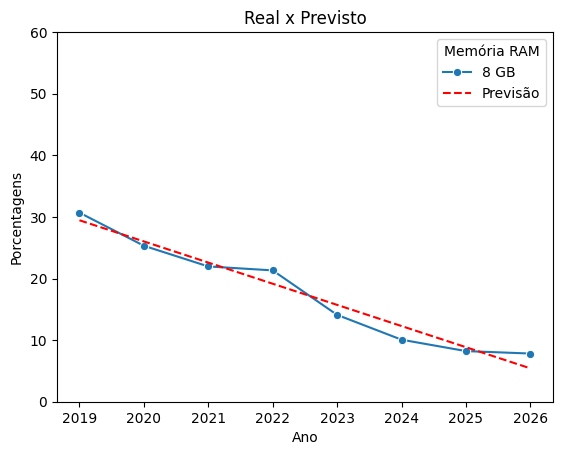

In [78]:
line = {'x': [2019, 2026], 'y': [f8(2019), f8(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_ram_8, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Memória RAM')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

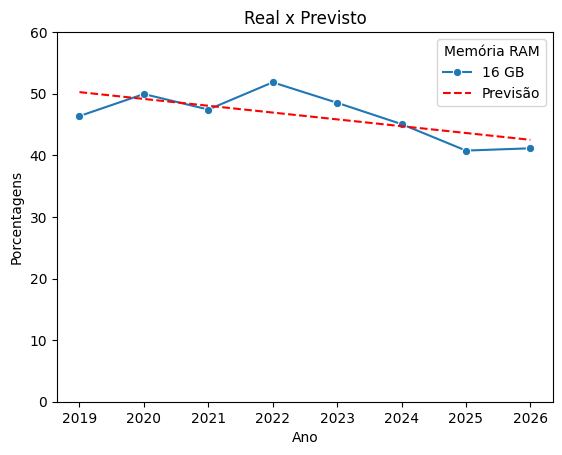

In [77]:
line = {'x': [2019, 2026], 'y': [f16(2019), f16(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_ram_16, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Memória RAM')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

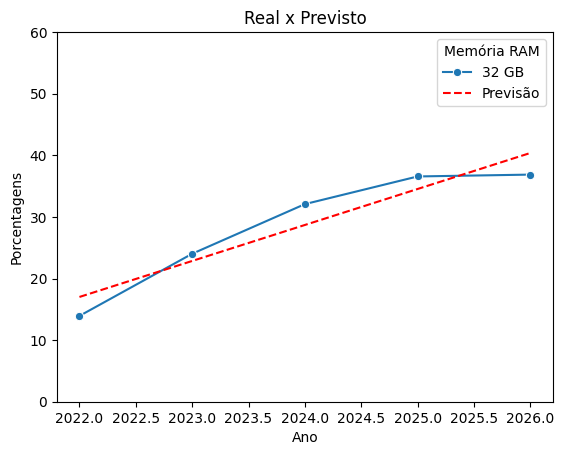

In [80]:
line = {'x': [2022, 2026], 'y': [f32(2022), f32(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_ram_32, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Memória RAM')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

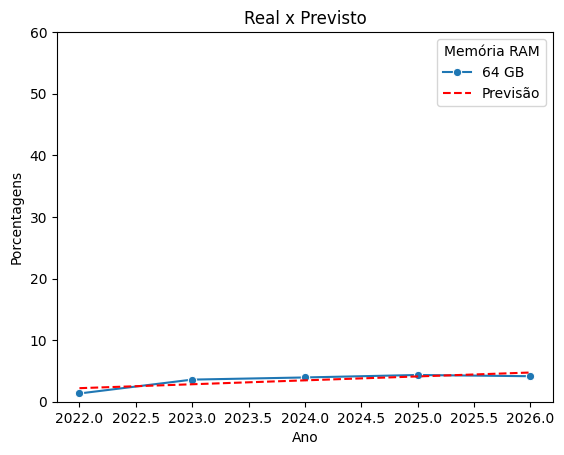

In [81]:
line = {'x': [2022, 2026], 'y': [f64(2022), f64(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_ram_64, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Memória RAM')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

In [73]:
dados = {
    'RAM' : ['8GB', '16GB', '32GB', '64GB'],
    'Porcentagem' : [f'{round(f8(2030), 2)}', f'{round(f16(2030), 2)}', f'{round(f32(2030), 2)}', f'{round(f64(2030), 2)}']
}

dados_ram = pd.DataFrame(dados)
dados_ram['Porcentagem'] = dados_ram['Porcentagem'].astype(float)
dados_ram

,RAM,Porcentagem
0,8GB,1.00
1,16GB,38.09
2,32GB,63.75
3,64GB,7.28


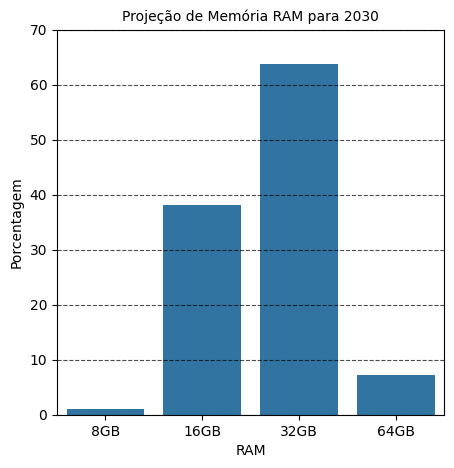

In [82]:
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=dados_ram, x='RAM', y='Porcentagem')
ax.invert_yaxis()
ax.set_ylim(0, 70)
ax.set_title('Projeção de Memória RAM para 2030', fontsize=10)
plt.grid(axis='y', color='black', linestyle='--', alpha=0.7)


## Análise das CPUs

In [15]:
df_cpus = df_anual[df_anual['Categoria'] == 'Physical CPUs']
df_cpus = df_cpus[( df_cpus['Especificação'] == '4 cpus') | 
                  (df_cpus['Especificação'] == '6 cpus') | 
                  (df_cpus['Especificação'] == '8 cpus') | 
                  (df_cpus['Especificação'] == '10 cpus') | 
                  (df_cpus['Especificação'] == '12 cpus') | 
                  (df_cpus['Especificação'] == '14 cpus') | 
                  (df_cpus['Especificação'] == '16 cpus')]
df_cpus.head(8)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
41,Physical CPUs,4 cpus,54.58,-1.43,2019
43,Physical CPUs,6 cpus,21.26,11.24,2019
45,Physical CPUs,8 cpus,4.40,2.61,2019
46,Physical CPUs,10 cpus,0.06,0.00,2019
48,Physical CPUs,12 cpus,0.14,0.10,2019
49,Physical CPUs,14 cpus,0.01,0.00,2019
51,Physical CPUs,16 cpus,0.05,0.01,2019
218,Physical CPUs,4 cpus,39.55,-10.80,2020


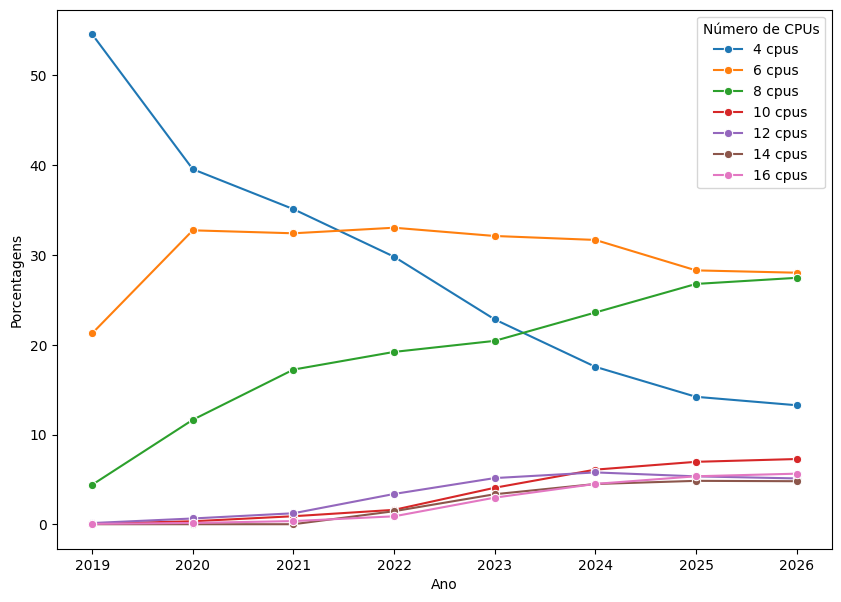

In [16]:
plt.figure(figsize=(10, 7))
ax = sns.lineplot(data=df_cpus, x='Ano', y='Porcentagens', hue='Especificação', marker='o')
ax.legend_.set_title(title="Número de CPUs")

In [17]:
df_cpus_4 = df_cpus[df_cpus['Especificação'] == '4 cpus']
df_cpus_6 = df_cpus[df_cpus['Especificação'] == '6 cpus']
df_cpus_8 = df_cpus[df_cpus['Especificação'] == '8 cpus']
df_cpus_10 = df_cpus[df_cpus['Especificação'] == '10 cpus']
df_cpus_12 = df_cpus[df_cpus['Especificação'] == '12 cpus']
df_cpus_14 = df_cpus[df_cpus['Especificação'] == '14 cpus']
df_cpus_16 = df_cpus[df_cpus['Especificação'] == '16 cpus']

In [18]:
result_4cpus = linregress(df_cpus_4['Ano'], df_cpus_4['Porcentagens'])
result_6cpus = linregress(df_cpus_6['Ano'], df_cpus_6['Porcentagens'])
result_8cpus = linregress(df_cpus_8['Ano'], df_cpus_8['Porcentagens'])
result_10cpus = linregress(df_cpus_10['Ano'], df_cpus_10['Porcentagens'])
result_12cpus = linregress(df_cpus_12['Ano'], df_cpus_12['Porcentagens'])
result_14cpus = linregress(df_cpus_14['Ano'], df_cpus_14['Porcentagens'])
result_16cpus = linregress(df_cpus_16['Ano'], df_cpus_16['Porcentagens'])

In [19]:
def f4_cpus(x):
    if (result_4cpus.slope * x + result_4cpus.intercept <= 0):
        return 1.0
    else:
        return result_4cpus.slope * x + result_4cpus.intercept
    
def f6_cpus(x):
    if (result_6cpus.slope * x + result_6cpus.intercept <= 0):
        return 1.0
    else:
        return result_6cpus.slope * x + result_6cpus.intercept

def f8_cpus(x):
    if (result_8cpus.slope * x + result_8cpus.intercept <= 0):
        return 1.0
    else:
        return result_8cpus.slope * x + result_8cpus.intercept

def f10_cpus(x):
    if (result_10cpus.slope * x + result_10cpus.intercept <= 0):
        return 1.0
    else:
        return result_10cpus.slope * x + result_10cpus.intercept

def f12_cpus(x):
    if (result_12cpus.slope * x + result_12cpus.intercept <= 0):
        return 1.0
    else:
        return result_12cpus.slope * x + result_12cpus.intercept

def f14_cpus(x):
    if (result_14cpus.slope * x + result_14cpus.intercept <= 0):
        return 1.0
    else:
        return result_14cpus.slope * x + result_14cpus.intercept

def f16_cpus(x):
    if (result_16cpus.slope * x + result_16cpus.intercept <= 0):
        return 1.0
    else:
        return result_16cpus.slope * x + result_16cpus.intercept

In [20]:
dados = {
    'CPUs' : ['4', '6', '8', '10', '12', '14', '16'],
    'Porcentagem' : [f'{round(f4_cpus(2030), 2)}',
                    f'{round(f6_cpus(2030), 2)}',
                    f'{round(f8_cpus(2030), 2)}',
                    f'{round(f10_cpus(2030), 2)}', 
                    f'{round(f12_cpus(2030), 2)}', 
                    f'{round(f14_cpus(2030), 2)}', 
                    f'{round(f16_cpus(2030), 2)}', ]
}

dados_cpus = pd.DataFrame(dados)
dados_cpus['Porcentagem'] = dados_cpus['Porcentagem'].astype(float)
dados_cpus

,CPUs,Porcentagem
0,4,1.00
1,6,31.89
2,8,41.81
3,10,12.48
4,12,9.92
5,14,8.89
6,16,9.60


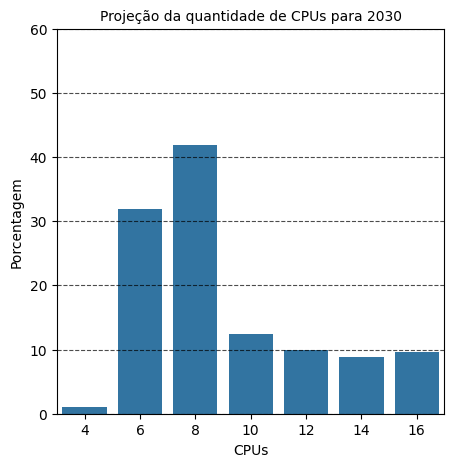

In [83]:
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=dados_cpus, x='CPUs', y='Porcentagem')
ax.invert_yaxis()
ax.set_ylim(0, 60)
ax.set_title('Projeção da quantidade de CPUs para 2030', fontsize=10)
plt.grid(axis='y', color='black', linestyle='--', alpha=0.7)

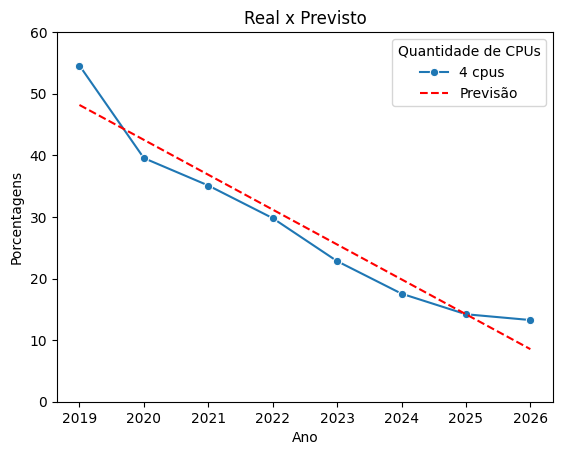

In [87]:
line = {'x': [2019, 2026], 'y': [f4_cpus(2019), f4_cpus(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_cpus_4, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Quantidade de CPUs')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

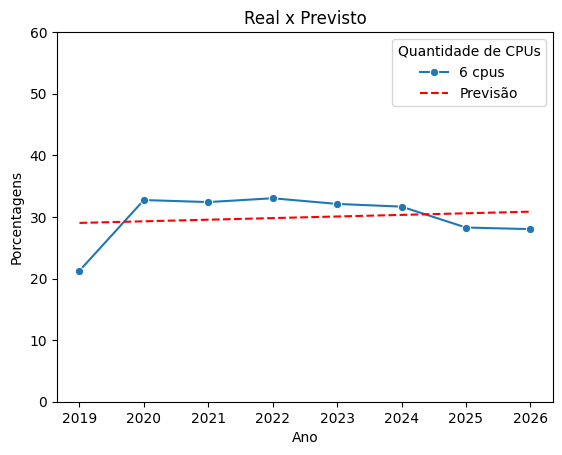

In [89]:
line = {'x': [2019, 2026], 'y': [f6_cpus(2019), f6_cpus(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_cpus_6, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Quantidade de CPUs')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

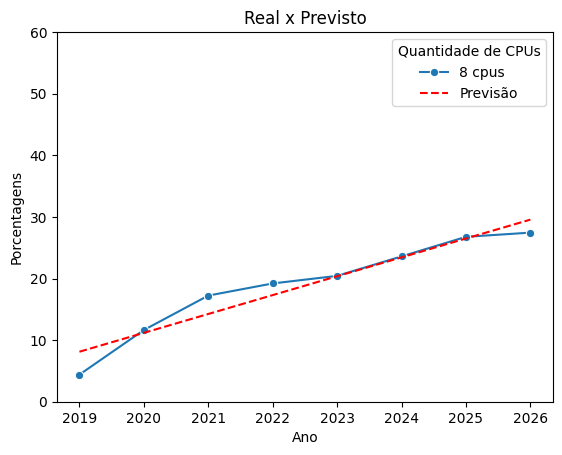

In [88]:
line = {'x': [2019, 2026], 'y': [f8_cpus(2019), f8_cpus(2026)]}
ax = sns.lineplot(x='Ano', y="Porcentagens", data=df_cpus_8, hue='Especificação', marker="o")
sns.lineplot(x='x', y='y', data=line, color='red', ls='--', label='Previsão')
ax.legend_.set_title('Quantidade de CPUs')
ax.set_title('Real x Previsto')
plt.ylim(0, 60)
plt.show()

## Análise Sistemas Operacionais

In [51]:
df_windows2026 = df_mensal[(df_mensal['Especificação'] == 'Windows 11 64 bit') | (df_mensal['Especificação'] == 'Windows 10 64 bit') ]
df_windows2026 = df_windows2026[df_windows2026['Ano'] == 2026]
df_windows2026

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
16276,OS Version,Windows 11 64 bit,66.71,0.11,Janeiro,2026
16277,OS Version,Windows 10 64 bit,27.79,0.28,Janeiro,2026
16492,OS Version,Windows 11 64 bit,56.28,-10.43,Fevereiro,2026
16493,OS Version,Windows 10 64 bit,40.25,12.46,Fevereiro,2026
16676,OS Version,Windows 11 64 bit,66.85,10.57,Março,2026
16677,OS Version,Windows 10 64 bit,25.36,-14.89,Março,2026
16890,OS Version,Windows 11 64 bit,67.74,0.89,Abril,2026
16891,OS Version,Windows 10 64 bit,25.63,0.27,Abril,2026
17109,OS Version,Windows 11 64 bit,69.76,2.02,Maio,2026
17110,OS Version,Windows 10 64 bit,23.99,-1.64,Maio,2026


In [52]:
df_windows2025 = df_mensal[(df_mensal['Especificação'] == 'Windows 11 64 bit') | (df_mensal['Especificação'] == 'Windows 10 64 bit') ]
df_windows2025 = df_windows2025[df_windows2025['Ano'] == 2025]
df_windows2025

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
13827,OS Version,Windows 11 64 bit,53.46,0.34,Janeiro,2025
13828,OS Version,Windows 10 64 bit,42.87,0.13,Janeiro,2025
14021,OS Version,Windows 10 64 bit,53.34,10.47,Fevereiro,2025
14022,OS Version,Windows 11 64 bit,44.10,-9.36,Fevereiro,2025
14203,OS Version,Windows 11 64 bit,55.34,11.24,Março,2025
14204,OS Version,Windows 10 64 bit,40.58,-12.76,Março,2025
14403,OS Version,Windows 11 64 bit,57.84,2.50,Abril,2025
14404,OS Version,Windows 10 64 bit,38.09,-2.49,Abril,2025
14604,OS Version,Windows 11 64 bit,58.30,0.46,Maio,2025
14605,OS Version,Windows 10 64 bit,37.00,-1.09,Maio,2025


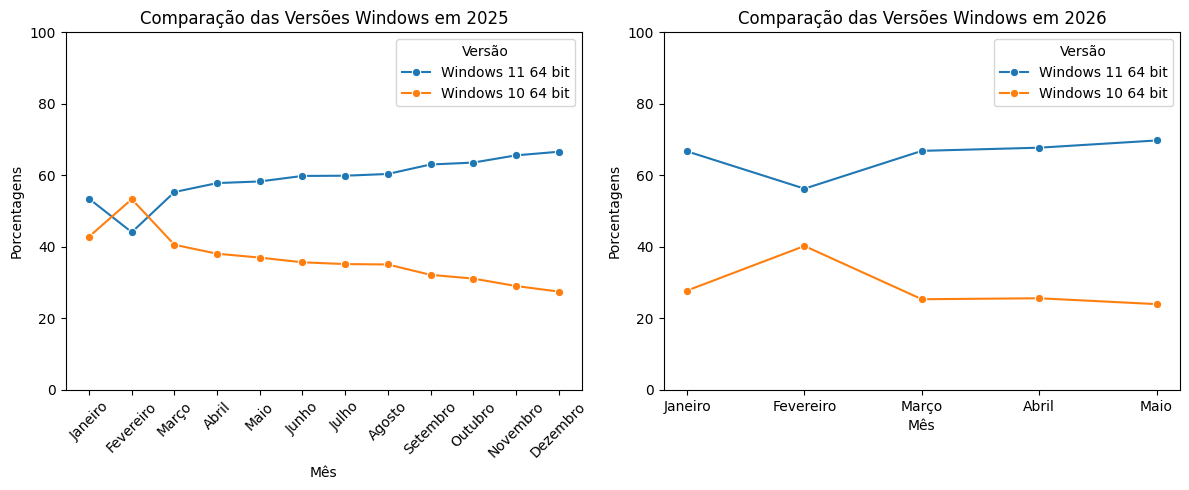

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(data=df_windows2025, x='Mês', y='Porcentagens', hue='Especificação', marker='o', ax=axes[0])
axes[0].set_title('Comparação das Versões Windows em 2025')
axes[0].legend_.set_title('Versão')
axes[0].set_ylim((0,100))
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=df_windows2026, x='Mês', y='Porcentagens', hue='Especificação', marker='o', ax=axes[1])
axes[1].set_title('Comparação das Versões Windows em 2026')
axes[1].legend_.set_title('Versão')
axes[1].set_ylim((0,100))
plt.ylim((0, 100))
plt.tight_layout()
plt.show()

In [29]:
df_OsVersion = df_anual[(df_anual['Especificação'] == 'OSX') | (df_anual['Especificação'] == 'Linux') ]
df_OsVersion

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
7,OS Version,OSX,2.47,-0.80,2019
16,OS Version,Linux,0.67,-0.15,2019
185,OS Version,OSX,2.74,-0.27,2020
194,OS Version,Linux,0.74,-0.16,2020
366,OS Version,OSX,2.70,-0.74,2021
378,OS Version,Linux,1.11,0.20,2021
566,OS Version,OSX,2.48,-0.29,2022
580,OS Version,Linux,1.38,0.32,2022
760,OS Version,OSX,1.63,-0.98,2023
768,OS Version,Linux,1.97,0.59,2023


<Axes: xlabel='Ano', ylabel='Porcentagens'>

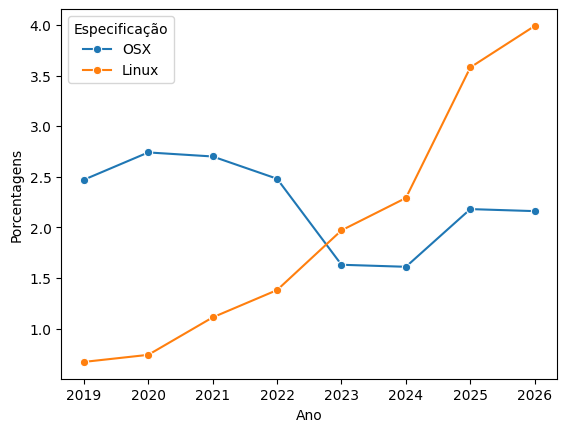

In [30]:
sns.lineplot(data=df_OsVersion, x='Ano', y='Porcentagens', hue='Especificação', marker='o')

## Análise Placa de Vídeo

In [31]:
df_video = df_anual[df_anual['Categoria'] == 'Video Card Description']
df_video

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
59,Video Card Description,NVIDIA GeForce GTX 1060,20.30,5.99,2019
60,Video Card Description,NVIDIA GeForce GTX 1050 Ti,9.23,0.24,2019
61,Video Card Description,NVIDIA GeForce GTX 1050,4.50,-0.49,2019
62,Video Card Description,NVIDIA GeForce GTX 1070,3.82,-0.37,2019
63,Video Card Description,NVIDIA GeForce GTX 960,3.70,0.33,2019
...,...,...,...,...,...
1564,Video Card Description,AMD Radeon Graphics,1.92,0.07,2026
1565,Video Card Description,Intel(R) Graphics,0.37,0.09,2026
1566,Video Card Description,AMD Radeon RX 5700 XT,0.57,0.00,2026
1567,Video Card Description,NVIDIA GeForce RTX 4060,3.55,-0.61,2026


In [32]:
df_video['Especificação'] = df_video['Especificação'].str.replace(r'(NVIDIA).*$', r'\1', regex=True).str.replace(r'(AMD).*$', r'\1', regex=True).str.replace(r'(Intel).*$', r'\1', regex=True).str.strip()
df_video

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
59,Video Card Description,NVIDIA,20.30,5.99,2019
60,Video Card Description,NVIDIA,9.23,0.24,2019
61,Video Card Description,NVIDIA,4.50,-0.49,2019
62,Video Card Description,NVIDIA,3.82,-0.37,2019
63,Video Card Description,NVIDIA,3.70,0.33,2019
...,...,...,...,...,...
1564,Video Card Description,AMD,1.92,0.07,2026
1565,Video Card Description,Intel,0.37,0.09,2026
1566,Video Card Description,AMD,0.57,0.00,2026
1567,Video Card Description,NVIDIA,3.55,-0.61,2026


In [33]:
df_video = df_video[(df_video['Especificação'] == 'NVIDIA') | (df_video['Especificação'] == 'AMD') |(df_video['Especificação'] == 'Intel')]
df_video

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
59,Video Card Description,NVIDIA,20.30,5.99,2019
60,Video Card Description,NVIDIA,9.23,0.24,2019
61,Video Card Description,NVIDIA,4.50,-0.49,2019
62,Video Card Description,NVIDIA,3.82,-0.37,2019
63,Video Card Description,NVIDIA,3.70,0.33,2019
...,...,...,...,...,...
1563,Video Card Description,AMD,0.34,0.02,2026
1564,Video Card Description,AMD,1.92,0.07,2026
1565,Video Card Description,Intel,0.37,0.09,2026
1566,Video Card Description,AMD,0.57,0.00,2026


In [34]:
distribuicao_video = df_video.groupby(['Especificação', 'Ano'])['Porcentagens'].sum().reset_index()
distribuicao_video

,Especificação,Ano,Porcentagens
0,AMD,2019,7.66
1,AMD,2020,9.99
2,AMD,2021,10.57
3,AMD,2022,10.62
4,AMD,2023,12.17
5,AMD,2024,16.44
6,AMD,2025,14.63
7,AMD,2026,14.40
8,Intel,2019,7.38
9,Intel,2020,7.12


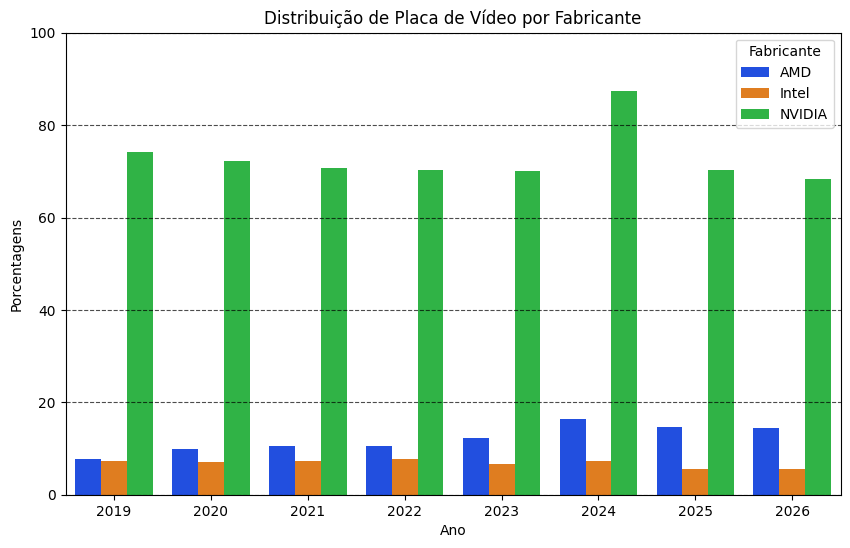

In [35]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=distribuicao_video, x='Ano', y='Porcentagens', hue='Especificação', palette='bright')
ax.legend_.set_title('Fabricante')
ax.set_title('Distribuição de Placa de Vídeo por Fabricante')
plt.ylim((0,100))
plt.grid(axis='y', color='black', linestyle='--', alpha=0.7)

In [36]:
cpus2020 = df_mensal[(df_mensal['Categoria'] == 'Physical CPUs') & (df_mensal['Ano'] == 2020)]
cpus2020['Especificação'] = cpus2020['Especificação'].str.replace(r'(\d+)+.*$', r'\1', regex=True).str.strip()
cpus2020["Especificação"] = pd.to_numeric(cpus2020["Especificação"], errors="coerce")
cpus2020['Especificação'] = cpus2020['Especificação'].fillna(0).astype(int)
cpus2020 = cpus2020[(cpus2020['Especificação'] <= 8) & (cpus2020['Especificação'] > 0) & ((cpus2020['Especificação'] % 2) == 0)]
cpus2020.head(15)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
2311,Physical CPUs,2,21.57,0.17,Janeiro,2020
2313,Physical CPUs,4,50.35,-1.56,Janeiro,2020
2315,Physical CPUs,6,20.06,0.42,Janeiro,2020
2317,Physical CPUs,8,5.71,0.93,Janeiro,2020
2505,Physical CPUs,2,22.03,0.46,Fevereiro,2020
2507,Physical CPUs,4,49.22,-1.13,Fevereiro,2020
2509,Physical CPUs,6,20.65,0.59,Fevereiro,2020
2511,Physical CPUs,8,5.84,0.13,Fevereiro,2020
2706,Physical CPUs,2,20.68,-1.35,Março,2020
2708,Physical CPUs,4,48.03,-1.19,Março,2020


In [37]:
cpus2021 = df_mensal[(df_mensal['Categoria'] == 'Physical CPUs') & (df_mensal['Ano'] == 2021)]
cpus2021['Especificação'] = cpus2021['Especificação'].str.replace(r'(\d+)+.*$', r'\1', regex=True).str.strip()
cpus2021["Especificação"] = pd.to_numeric(cpus2021["Especificação"], errors="coerce")
cpus2021['Especificação'] = cpus2021['Especificação'].fillna(0).astype(int)
cpus2021 = cpus2021[(cpus2021['Especificação'] <= 8) & (cpus2021['Especificação'] > 0) & ((cpus2021['Especificação'] % 2) == 0)]
cpus2021.head(15)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
4636,Physical CPUs,2,15.66,1.41,Janeiro,2021
4638,Physical CPUs,4,42.94,2.75,Janeiro,2021
4640,Physical CPUs,6,27.87,-3.89,Janeiro,2021
4642,Physical CPUs,8,11.04,-0.47,Janeiro,2021
4828,Physical CPUs,2,14.74,-0.92,Fevereiro,2021
4830,Physical CPUs,4,41.95,-0.99,Fevereiro,2021
4832,Physical CPUs,6,28.76,0.89,Fevereiro,2021
4834,Physical CPUs,8,11.95,0.91,Fevereiro,2021
5018,Physical CPUs,2,14.33,-0.41,Março,2021
5020,Physical CPUs,4,41.40,-0.55,Março,2021


In [42]:
cpus2023 = df_mensal[(df_mensal['Categoria'] == 'Physical CPUs') & (df_mensal['Ano'] == 2023)]
cpus2023['Especificação'] = cpus2023['Especificação'].str.replace(r'(\d+)+.*$', r'\1', regex=True).str.strip()
cpus2023["Especificação"] = pd.to_numeric(cpus2023["Especificação"], errors="coerce")
cpus2023['Especificação'] = cpus2023['Especificação'].fillna(0).astype(int)
cpus2023 = cpus2023[(cpus2023['Especificação'] <= 8) & (cpus2023['Especificação'] > 0) & ((cpus2023['Especificação'] % 2) == 0)]
cpus2023.head(15)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
9232,Physical CPUs,2,9.95,0.06,Janeiro,2023
9234,Physical CPUs,4,29.51,-0.29,Janeiro,2023
9236,Physical CPUs,6,32.08,-0.95,Janeiro,2023
9238,Physical CPUs,8,19.55,0.35,Janeiro,2023
9430,Physical CPUs,2,9.00,-0.95,Fevereiro,2023
9432,Physical CPUs,4,27.96,-1.55,Fevereiro,2023
9434,Physical CPUs,6,33.42,1.34,Fevereiro,2023
9436,Physical CPUs,8,20.09,0.54,Fevereiro,2023
9616,Physical CPUs,2,5.41,-3.59,Março,2023
9618,Physical CPUs,4,20.94,-7.02,Março,2023


(0.0, 60.0)

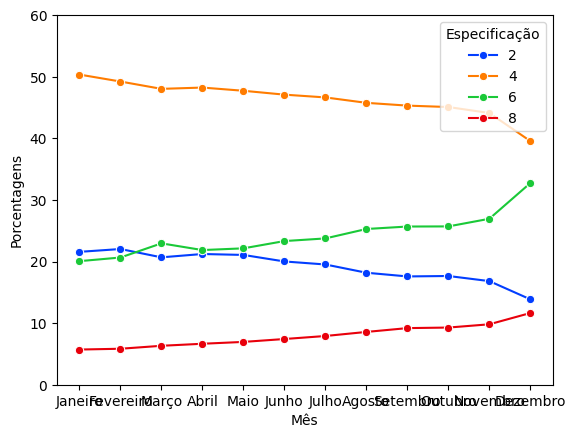

In [39]:
sns.lineplot(data=cpus2020, x='Mês', y='Porcentagens', hue='Especificação', palette='bright', marker='o')
plt.ylim((0, 60))

(0.0, 60.0)

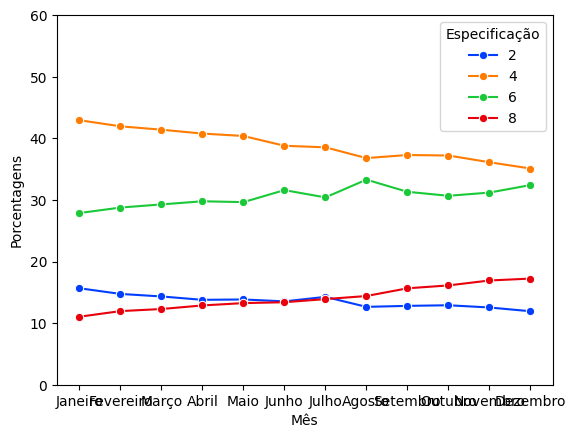

In [40]:
sns.lineplot(data=cpus2021, x='Mês', y='Porcentagens', hue='Especificação', palette='bright', marker='o')
plt.ylim((0, 60))

(0.0, 60.0)

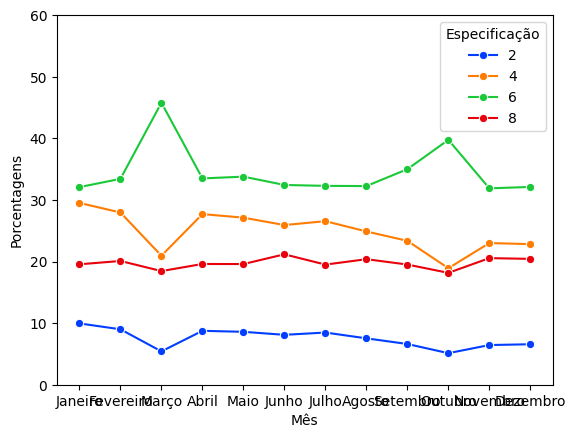

In [43]:
sns.lineplot(data=cpus2023, x='Mês', y='Porcentagens', hue='Especificação', palette='bright', marker='o')
plt.ylim((0, 60))